In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.quick_calculate import FittingFunction
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
manual_db = pl.read_parquet(r".database\manual_detection_database.parquet")
auto_db = dp.combined_mask_no_merge.filter(pl.col("face") == "posx").collect()

manual_db

i,j,manual_detect_boulder_id,face
i32,i32,u32,str
7661,5626,8092974,"""posx"""
7661,5627,8092974,"""posx"""
7661,5628,8092974,"""posx"""
7661,5629,8092974,"""posx"""
7661,5630,8092974,"""posx"""
…,…,…,…
40,2454,11742965,"""posx"""
40,2455,11742965,"""posx"""
40,2456,11742965,"""posx"""


In [3]:
auto_db_agg = auto_db.group_by("row_id").agg(pl.len().alias("auto_boulder_size"))
manual_db_agg = manual_db.group_by("manual_detect_boulder_id").agg(pl.len().alias("manual_boulder_size"))

db_intersections = manual_db.join(
    auto_db,
    on=["i", "j"],
    how="inner",
).select("i", "j", "lod_level", "lod_code", "row_id", "manual_detect_boulder_id")

db_intersections

i,j,lod_level,lod_code,row_id,manual_detect_boulder_id
i32,i32,u8,str,u32,u32
64,2480,0,"""""",6,11742965
64,2481,0,"""""",6,11742965
64,2482,0,"""""",6,11742965
64,2483,0,"""""",6,11742965
64,2484,0,"""""",6,11742965
…,…,…,…,…,…
7185,7880,4,"""DDDB""",3870233,5788426
7186,7879,4,"""DDDB""",3870233,5788426
7186,7880,4,"""DDDB""",3870233,5788426


In [4]:
db_intersections_agg = db_intersections.group_by("manual_detect_boulder_id", "row_id").agg(
    pl.len().alias("overlap"),
    pl.col("lod_level").first(),
    pl.col("lod_code").first()
)

db_jaccard = db_intersections_agg.join(
    auto_db_agg,
    on="row_id",
    how="left",
).join(
    manual_db_agg,
    on="manual_detect_boulder_id",
    how="left",
).with_columns(
    (
        pl.col("overlap") / (pl.col("auto_boulder_size") + pl.col("manual_boulder_size") - pl.col("overlap"))
    ).alias("Jaccard_index")
)

db_jaccard

manual_detect_boulder_id,row_id,overlap,lod_level,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index
u32,u32,u32,u8,str,u32,u32,f64
6025225,3049597,1,3,"""DAC""",136,18780,0.000053
418076,3162861,12,4,"""DADD""",267,24333,0.000488
7835492,3174675,1,2,"""DB""",1200,21002,0.000045
4899995,3174725,20773,2,"""DB""",21792,24539,0.812779
9340371,774148,72,4,"""ADAC""",1828,82774,0.000852
…,…,…,…,…,…,…,…
5136384,356948,134,4,"""ABBD""",134,248654,0.000539
5136384,357007,25,4,"""ABBD""",25,248654,0.000101
5136384,357052,30,4,"""ABBD""",120,248654,0.000121


In [5]:
db_jaccard_agg = (
    db_jaccard
    .group_by(["lod_level", "manual_detect_boulder_id"])
    .agg(
        pl.all().get(
            pl.col("Jaccard_index").arg_max()
        )
    )
).with_columns(
    (pl.col("manual_boulder_size") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size"),
    (pl.col("auto_boulder_size") / pl.col("manual_boulder_size")).alias("area_diff_factor")
)

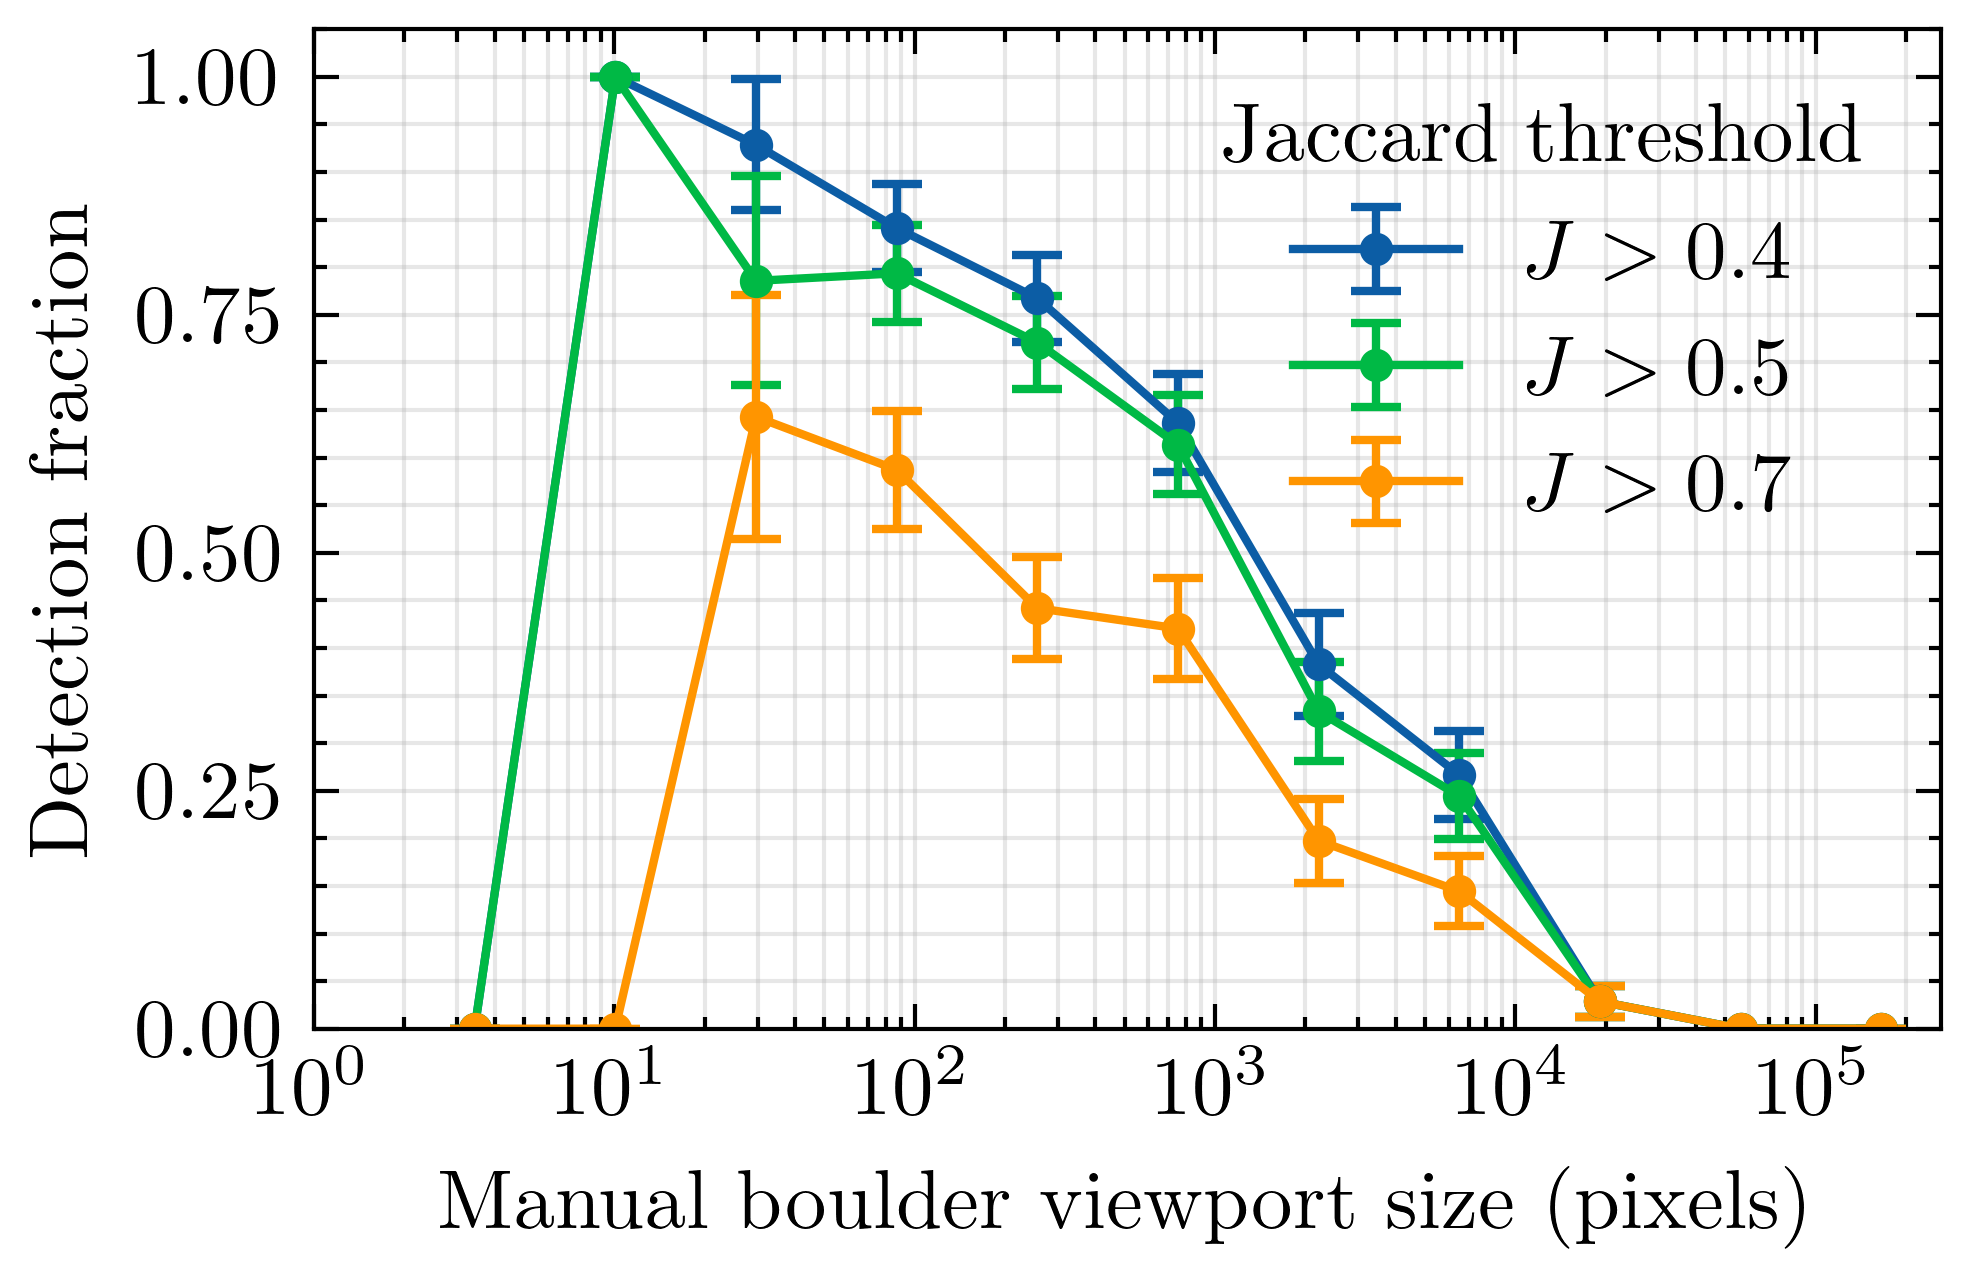

In [8]:
x = db_jaccard_agg["viewport_size"].to_numpy()
j = db_jaccard_agg["Jaccard_index"].to_numpy()

# 8 logarithmic bins
bins = np.geomspace(x.min(), x.max(), 12)
centres = np.sqrt(bins[:-1] * bins[1:])

total, _ = np.histogram(x, bins=bins)

thresholds = [0.4, 0.5, 0.7]

# plt.figure(figsize=(8, 5))

for thresh in thresholds:
    success, _ = np.histogram(x[j > thresh], bins=bins)

    rate = np.divide(
        success,
        total,
        out=np.full_like(success, np.nan, dtype=float),
        where=total > 0,
    )

    err = np.sqrt(rate * (1 - rate) / total)
    err[total == 0] = np.nan

    plt.errorbar(
        centres,
        rate,
        yerr=err,
        marker=".",
        capsize=3,
        label=f"$J > {thresh}$",
    )

plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlim(1, 512*512)
plt.xlabel("Manual boulder viewport size (pixels)")
plt.ylabel("Detection fraction")
plt.grid(True, which="both", alpha=0.3)
plt.legend(title="Jaccard threshold")
plt.savefig(".plots/S_from_manual_detection.png")
plt.show()

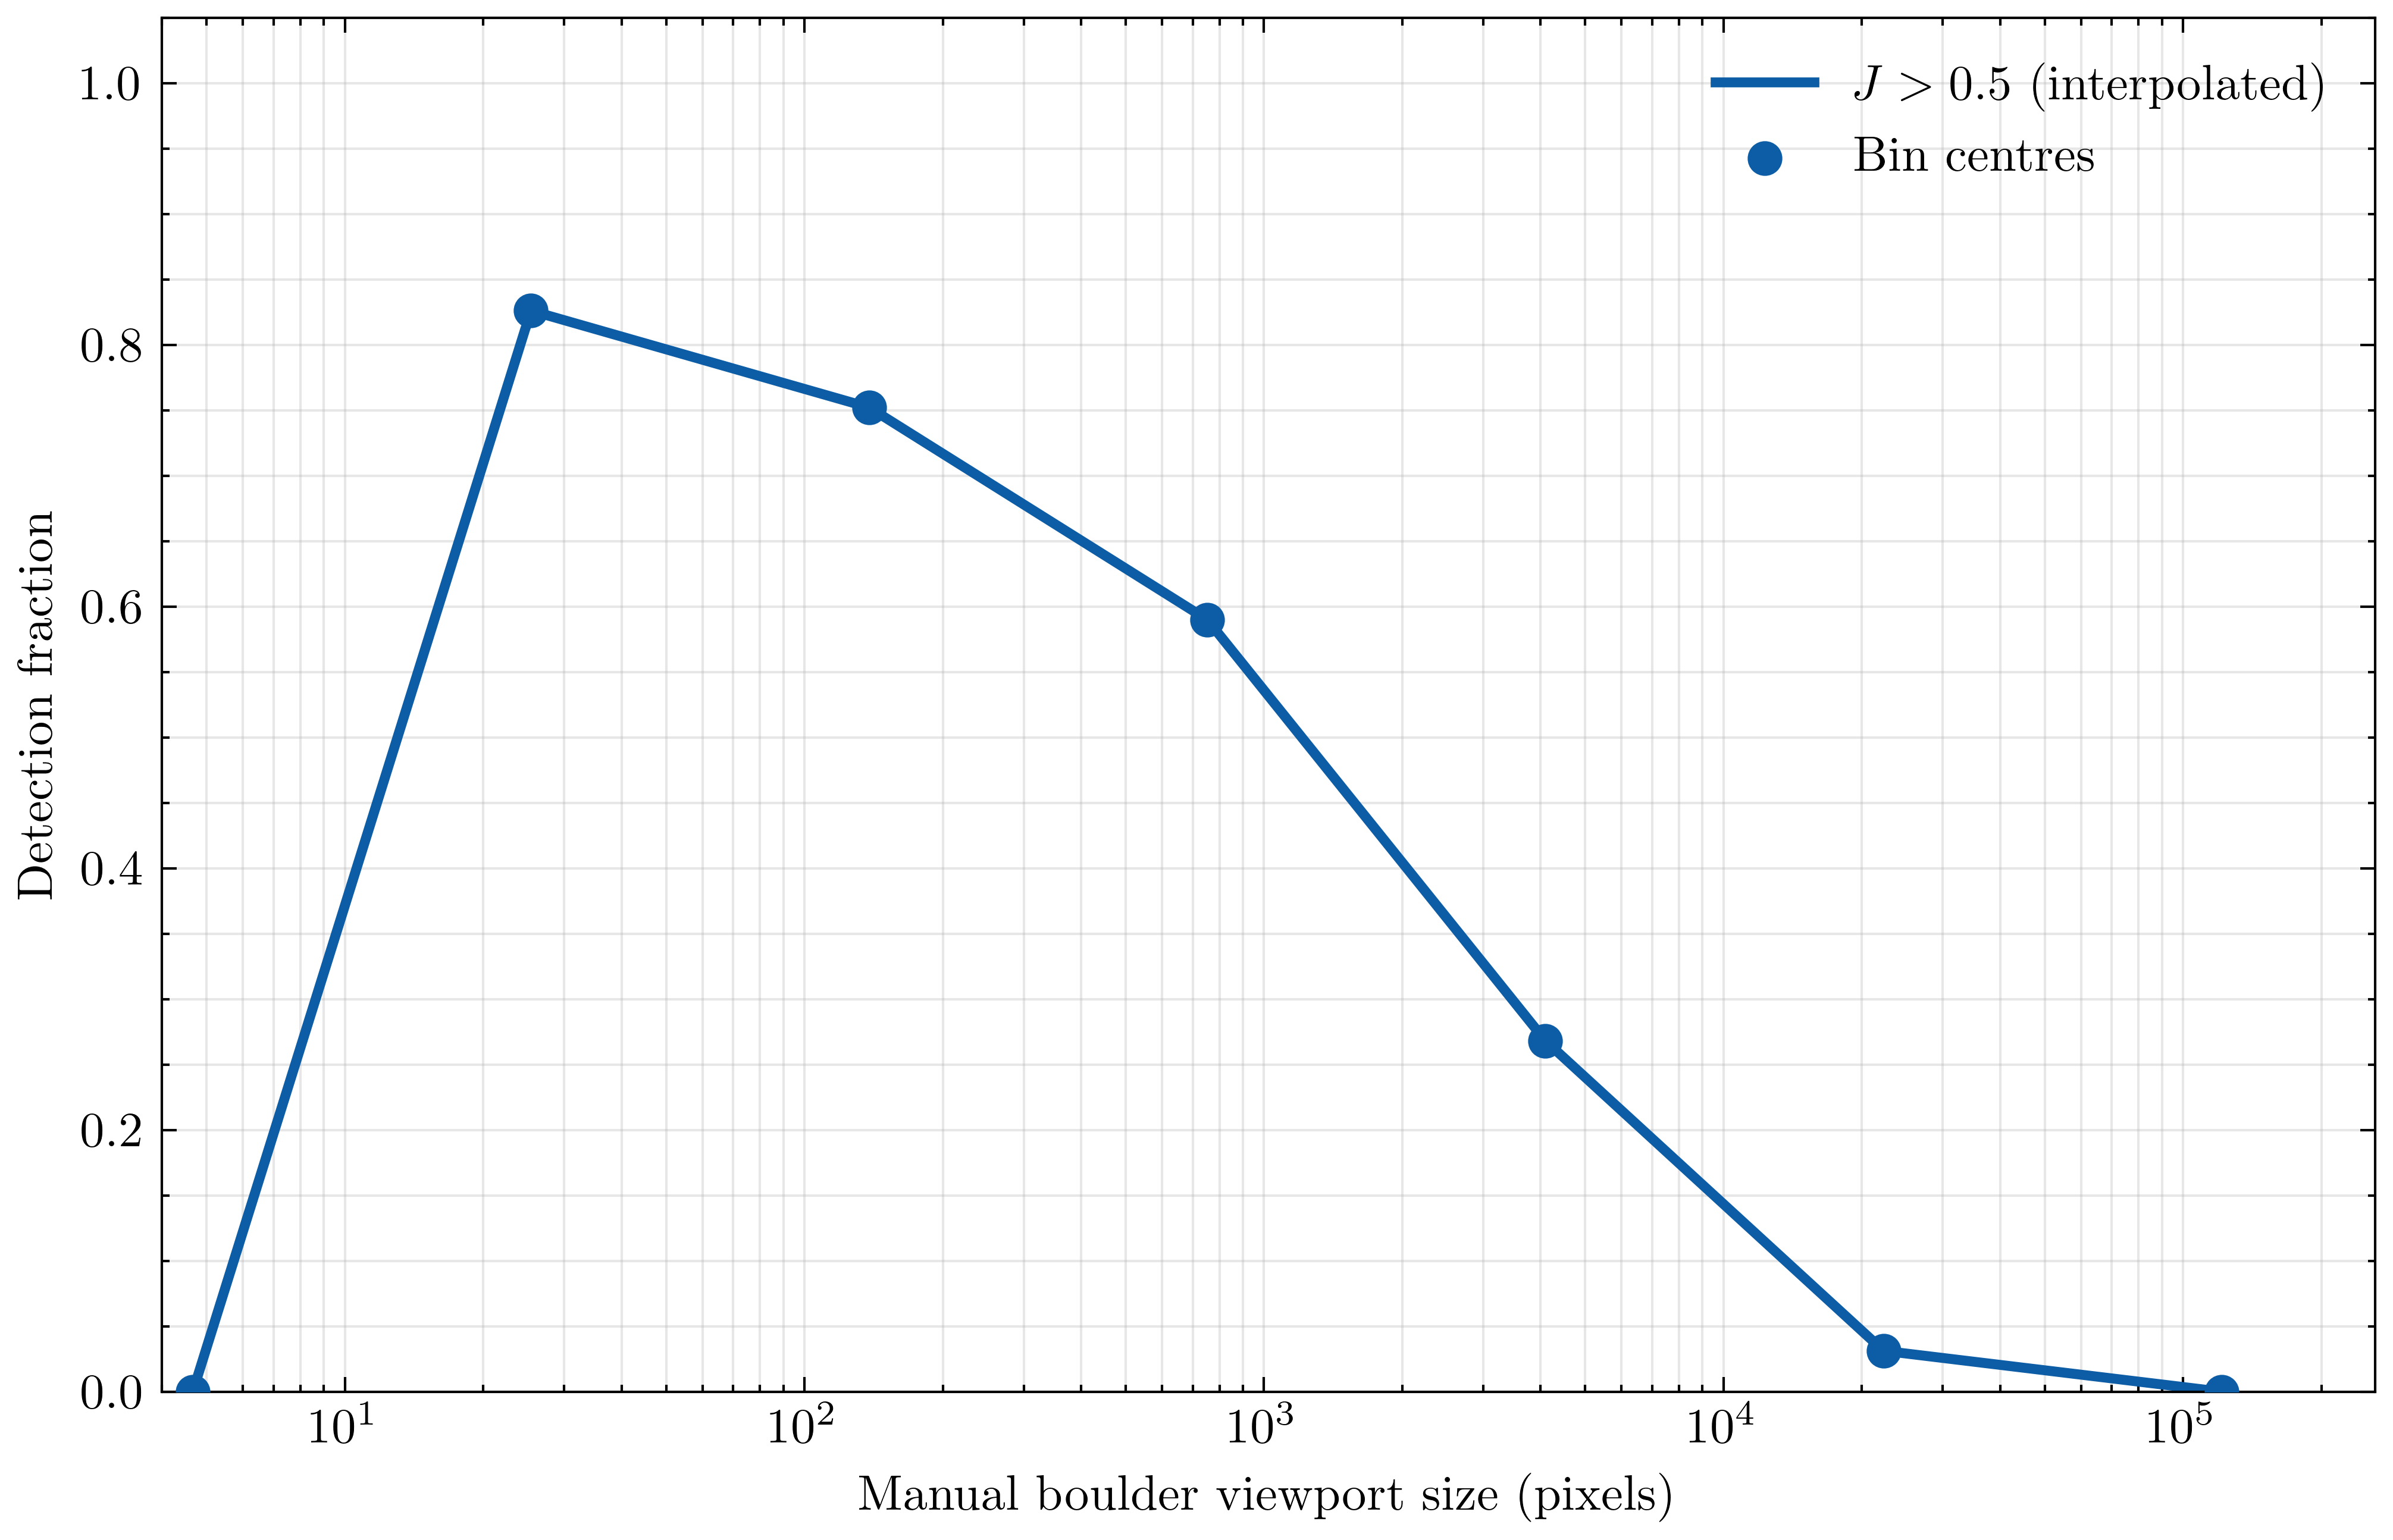

In [ ]:
from scipy.interpolate import interp1d

# Logarithmic bins
bins = np.geomspace(x.min(), x.max(), 8)
centres = np.sqrt(bins[:-1] * bins[1:])

total, _ = np.histogram(x, bins=bins)
success, _ = np.histogram(x[j > 0.5], bins=bins)

rate = np.divide(
    success,
    total,
    out=np.full_like(success, np.nan, dtype=float),
    where=total > 0,
)

# Keep only valid bins
mask = np.isfinite(rate)

# Interpolate in log-space
interp = interp1d(
    np.log10(centres[mask]),
    rate[mask],
    kind="linear",          # or "linear"
    bounds_error=False,
    fill_value=np.nan,
)

x_smooth = np.geomspace(centres[mask].min(), centres[mask].max(), 300)
y_smooth = interp(np.log10(x_smooth))

plt.figure(figsize=(8,5))
plt.plot(x_smooth, y_smooth, lw=2, label=r"$J>0.5$ (interpolated)")
plt.scatter(centres, rate, color="C0", zorder=3, label="Bin centres")

plt.xscale("log")
plt.xlim(4, 512*512)
plt.ylim(0, 1.05)
plt.xlabel("Manual boulder viewport size (pixels)")
plt.ylabel("Detection fraction")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.show()

In [ ]:
def approximate_S(J_threshold : float, samples : int = 1000):
    bins = np.geomspace(x.min(), x.max(), 8)
    centres = np.sqrt(bins[:-1] * bins[1:])

    total, _ = np.histogram(x, bins=bins)
    success, _ = np.histogram(x[j > J_threshold], bins=bins)

    rate = np.divide(
        success,
        total,
        out=np.full_like(success, np.nan, dtype=float),
        where=total > 0,
    )

    # Keep only valid bins
    mask = np.isfinite(rate)

    # Interpolate in log-space
    interp = interp1d(
        np.log10(centres[mask]),
        rate[mask],
        kind="linear",          # or "linear"
        bounds_error=False,
        fill_value=np.nan,
    )

    x_smooth = np.geomspace(centres[mask].min(), centres[mask].max(), samples)
    y_smooth = interp(np.log10(x_smooth))

    return pl.DataFrame({
            "view_port_alpha" : x_smooth,
            "p_detection" : y_smooth
        }).with_columns(
            pl.lit(J_threshold).alias("J_threshold")
        )

In [ ]:
df = pl.concat([approximate_S(j) for j in [0.2, 0.3, 0.5, 0.7]])

df.write_parquet(".database/S_manual_interp.parquet")